In [1]:
import subprocess
import pkg_resources
def check_and_update_yfinance():
    try:
        # Check the installed version of yfinance
        installed_version = pkg_resources.get_distribution("yfinance").version
        print(f"Currently installed yfinance version: {installed_version}")
    except pkg_resources.DistributionNotFound:
        print("yfinance is not installed.")
        installed_version = None
    # Update or install the latest version
    print("Checking for the latest version of yfinance...")
    try:
        subprocess.check_call(["pip", "install", "--upgrade", "yfinance"])
        print("yfinance has been updated to the latest version.")
    except subprocess.CalledProcessError as e:
        print("An error occurred while updating yfinance:", e)
if __name__ == "__main__":
    check_and_update_yfinance()

Currently installed yfinance version: 0.2.50
Checking for the latest version of yfinance...
yfinance has been updated to the latest version.


In [2]:
from IPython.display import display, Math, Latex

import pandas as pd
import numpy as np
import numpy_financial as npf
import yfinance as yf
import matplotlib.pyplot as plt
import random
from datetime import datetime
import itertools # Library for creating and using "Iterators" on multiple python types.


In [3]:
investment_size = 1000000
min_stocks = 12
max_stocks = 24
flat_fee = 3.95
fee_per_share = 0.001
ticker_file = pd.read_csv('Tickers_Example.csv', header=None)
ticker_file.rename(columns={0: 'name'}, inplace=True)

In [4]:
def clean_data(tickers):
    filtered_stocks = pd.DataFrame()
    start_date = "2023-10-01"
    end_date = "2024-09-30"
    for ticker in tickers['name']:
        try:
            stock = yf.Ticker(ticker)
            info = stock.fast_info
            if info['currency'] not in ["USD", "CAD"]: # Enusring stock is listed, traded in CAD or USD
                continue
    
            hist = stock.history(start=start_date, end=end_date, interval="1d")
            hist['Month'] = hist.index.to_period('M')
            monthly_data = hist.groupby('Month').filter(lambda x: len(x) >= 18)

            avg_monthly_volume = monthly_data.groupby('Month')['Volume'].mean().mean()
            if avg_monthly_volume >= 100000:
                filtered_stocks = pd.concat([filtered_stocks, pd.DataFrame({"Ticker": [ticker]})])
                
        except Exception as e:
            continue
    
    return filtered_stocks.reset_index(drop=True)

In [5]:
ticker_file = clean_data(ticker_file)

/var/folders/7x/z5l3v4x13gv5wlh0qdjwgllh0000gn/T/ipykernel_19102/194688612.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hist['Month'] = hist.index.to_period('M')
/var/folders/7x/z5l3v4x13gv5wlh0qdjwgllh0000gn/T/ipykernel_19102/194688612.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hist['Month'] = hist.index.to_period('M')
/var/folders/7x/z5l3v4x13gv5wlh0qdjwgllh0000gn/T/ipykernel_19102/194688612.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hist['Month'] = hist.index.to_period('M')
/var/folders/7x/z5l3v4x13gv5wlh0qdjwgllh0000gn/T/ipykernel_19102/194688612.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hist['Month'] = hist.index.to_period('M')
$AGN: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
/var/folders/7

In [6]:
def getBeta(cur_ticker):
    SP_ticker = '^GSPC'

    cur_stock = yf.Ticker(cur_ticker)
    SP_index = yf.Ticker(SP_ticker)

    # Will edit these later
    start_date = '2023-11-14'
    end_date = '2024-11-21'

    cur_stock_hist = cur_stock.history(start=start_date, end=end_date)
    SP_index_hist = SP_index.history(start=start_date, end=end_date)

    prices = pd.DataFrame()
    prices[cur_ticker] = pd.DataFrame(cur_stock_hist['Close'])
    prices['S&P Index'] = SP_index_hist['Close']

    daily_returns = prices.pct_change(fill_method=None).dropna()
    daily_returns.drop(index=daily_returns.index[0], inplace=True)

    SP_var = daily_returns['S&P Index'].var()
    SP_beta = daily_returns.cov() / SP_var
    currency = cur_stock.fast_info.currency
    todays_price = cur_stock.fast_info.last_price

    if currency == 'USD':
        cadusd = yf.Ticker('CADUSD=x')
        exchange = cadusd.fast_info.last_price
        todays_price = todays_price / exchange

    return SP_beta.iat[0,1], todays_price

In [7]:
# Gets average of daily growth
def getGrowth(cur_ticker):
    # Fetch data for current stock
    cur_stock = yf.Ticker(cur_ticker)
    start_date = '2023-11-14'
    end_date = '2024-11-21'
    cur_stock_hist = cur_stock.history(start=start_date, end=end_date)

    prices = pd.DataFrame()
    prices[cur_ticker] = cur_stock_hist['Close']
    
    daily_returns = prices.pct_change(fill_method=None).dropna()
    SP_growth = daily_returns.mean()
    
    return SP_growth[cur_ticker] * 100

In [8]:
def getVolatility(cur_ticker):
    start_date = '2023-11-14'
    end_date = '2024-11-21'
    stock_data = yf.Ticker(cur_ticker).history(start=start_date, end=end_date)
    stock_data['Daily Return'] = stock_data['Close'].pct_change(fill_method=None).dropna()
    
    volatility = stock_data['Daily Return'].std()
    return volatility

In [9]:

# Initialize the lists
stock_data = []
beta_data = []
volatility_data = []
growth_data = []

# Iterate through the tickers and gather data
for i in range(len(ticker_file)):
    cur_ticker = ticker_file['Ticker'].iloc[i]
    cur_stock = yf.Ticker(cur_ticker)
    start_date = '2023-11-14'
    end_date = '2024-11-21'
    cur_stock_hist = cur_stock.history(start=start_date, end=end_date)['Close']

    # Getting important statistics per stock
    beta, price = getBeta(cur_ticker)
    beta_data.append({"name": cur_ticker, "beta": beta})
    growth = getGrowth(cur_ticker)
    growth_data.append({"name": cur_ticker, "growth": growth})
    volatility = getVolatility(cur_ticker)
    volatility_data.append({"name": cur_ticker, "volatility": volatility})

    # Store combined stock details
    stock_details = {
        "name": cur_ticker,
        "beta": beta,
        "growth": growth,
        "volatility": volatility,
        "price": price,
        "price_history": cur_stock_hist
    }
    stock_data.append(stock_details)

# Sort the data by each criterion
sorted_betas = sorted(beta_data, key=lambda d: d['beta'], reverse=True)
sorted_growth = sorted(growth_data, key=lambda d: d['growth'], reverse=True)
sorted_volatility = sorted(volatility_data, key=lambda d: d['volatility'], reverse=True)

# Combine the lists into one iterable
lists = [sorted_betas, sorted_growth, sorted_volatility]
weights = [0.4, 0.3, 0.3]  # Corresponding weights for beta, growth, and volatility

# Step 1: Calculate weighted average index position for each stock
index_map = {}
for weight, lst in zip(weights, lists):
    for index, stock in enumerate(lst):
        name = stock["name"]
        if name not in index_map:
            index_map[name] = 0
        # Add the weighted index to the total
        index_map[name] += index * weight

# Step 2: Convert index_map to a list of dictionaries for sorting
weighted_positions = [
    {"name": name, "weighted_index": total_index}
    for name, total_index in index_map.items()
]

# Step 3: Sort stocks by their weighted index
sorted_by_weighted = sorted(weighted_positions, key=lambda x: x["weighted_index"])

# Final result: A list of stocks sorted by the weighted average of their index positions
result = [{"name": stock["name"], "weighted_index": stock["weighted_index"]} for stock in sorted_by_weighted]


In [10]:
best_stocks = []
for i in range(24):
    best_stocks += [result[i]["name"]]

In [11]:
filtered_stocks = []
for stock in best_stocks:
    for stock_stats in stock_data:
        if (stock == stock_stats["name"]):
            filtered_stocks += [stock_stats]

filtered_stocks

[{'name': 'SHOP.TO',
  'beta': 1.6907375909160378,
  'growth': 0.23905400676089805,
  'volatility': 0.03207653792469171,
  'price': 148.80999755859375,
  'price_history': Date
  2023-11-14 00:00:00-05:00     89.769997
  2023-11-15 00:00:00-05:00     92.849998
  2023-11-16 00:00:00-05:00     92.690002
  2023-11-17 00:00:00-05:00     93.870003
  2023-11-20 00:00:00-05:00     95.449997
                                  ...    
  2024-11-14 00:00:00-05:00    153.429993
  2024-11-15 00:00:00-05:00    152.869995
  2024-11-18 00:00:00-05:00    148.490005
  2024-11-19 00:00:00-05:00    145.990005
  2024-11-20 00:00:00-05:00    145.339996
  Name: Close, Length: 257, dtype: float64},
 {'name': 'QCOM',
  'beta': 2.0099074276516573,
  'growth': 0.11126596549459736,
  'volatility': 0.023769059225063168,
  'price': 217.23826838805715,
  'price_history': Date
  2023-11-14 00:00:00-05:00    124.756920
  2023-11-15 00:00:00-05:00    126.285042
  2023-11-16 00:00:00-05:00    126.069527
  2023-11-17 00:0

In [12]:
def generate_numbers(n, min_value, max_value, total_sum):
    total_lower = n * min_value
    total_upper = n * max_value
    if total_sum < total_lower or total_sum > total_upper:
        raise ValueError("Cannot generate numbers with the given constraints.")

    # Calculate the adjusted sum we need to distribute
    remaining_sum = total_sum - total_lower
    adjusted_upper_bounds = [max_value - min_value] * n

    # Generate initial random values
    u = [random.random() for _ in range(n)]
    adjusted_weights = [u_i * adjusted_upper_bounds[i] for i, u_i in enumerate(u)]
    adjusted_weights_sum = np.sum(adjusted_weights)

    # Scale the weights to match the remaining sum
    scaling_factor = remaining_sum / adjusted_weights_sum
    adjusted_weights = [w_i * scaling_factor for w_i in adjusted_weights]

    # Compute the final values
    x = [min_value + w_i for w_i in adjusted_weights]

    return x

In [13]:
TSX_index = yf.Ticker('XIU.TO')
SP_index = yf.Ticker('^GSPC')
cadusd = yf.Ticker('CADUSD=x')

# Will edit these later
start_date = '2023-11-14'
end_date = '2024-11-21'

TSX_index_hist = TSX_index.history(start=start_date, end=end_date)['Close']
TSX_index_hist.index = TSX_index_hist.index.strftime('%Y-%m-%d')
SP_index_hist = SP_index.history(start=start_date, end=end_date)['Close']
SP_index_hist.index = SP_index_hist.index.strftime('%Y-%m-%d')
cadusd_history = cadusd.history(start=start_date, end=end_date)['Close']
cadusd_history.index = cadusd_history.index.strftime('%Y-%m-%d')

SP_index_hist = SP_index_hist / cadusd_history

benchmark = (TSX_index_hist + SP_index_hist) / 2

for stock in filtered_stocks:
    stock["price_history"].index = stock["price_history"].index.strftime('%Y-%m-%d')

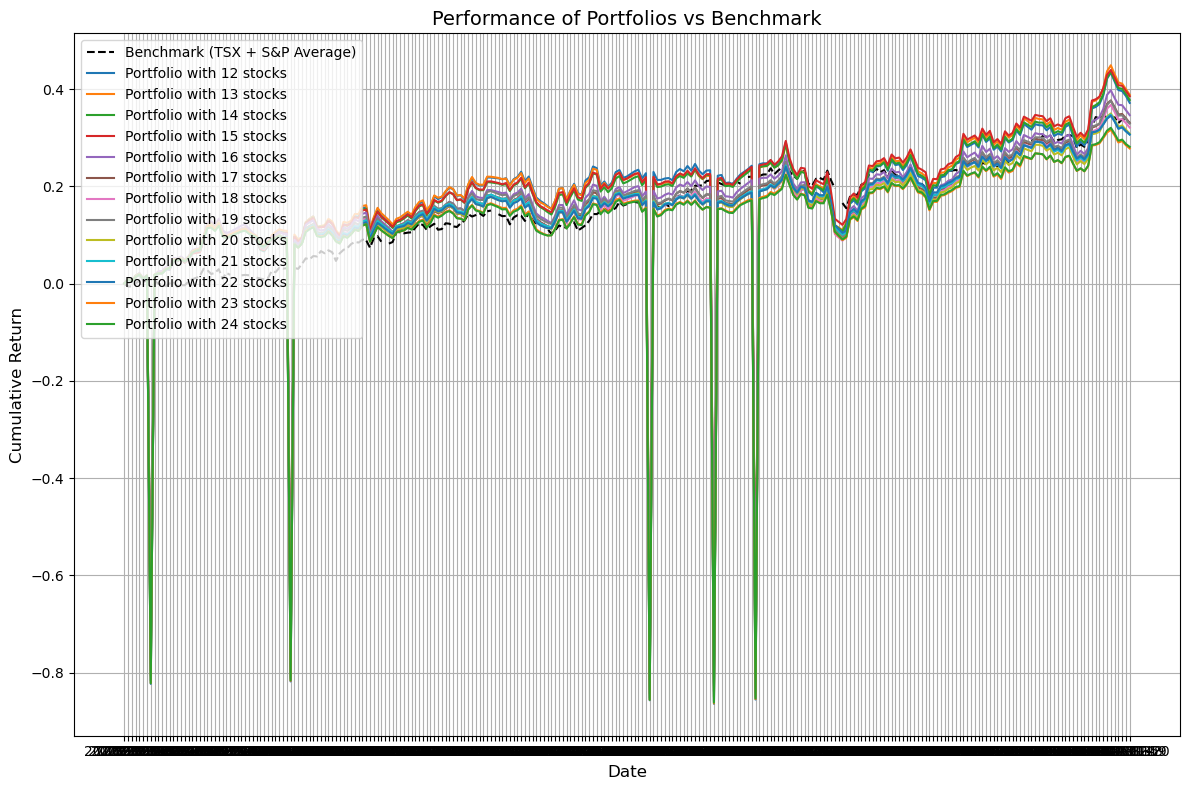

In [ ]:
def make_portfolios(stock_details, budget):
    strongest_portfolios = {}
    back_testing_portfolios = {}
    benchmark = (TSX_index_hist + SP_index_hist) / 2

    for n in range(12, 25):  # Loop through the number of stocks in the portfolio
        best_portfolio = None
        best_portfolio_backtesting = None
        best_invest_coeff = float('-inf')

        for j in range(1000):  # Create 100 portfolios with different weights for the current number of stocks
            stocks = stock_details[:n]
            max_weight = 15
            min_weight = 100 / (2 * n)
            generate = True
            
            # Generate valid weights for the portfolio
            while generate:
                weights = generate_numbers(n, min_weight, max_weight, 100)
                if all(min_weight <= weight <= max_weight for weight in weights):
                    generate = False
            
            weights.sort(reverse=True)

            current_portfolio = pd.DataFrame()
            fees_spent = 0
            total_spent = 0

            # Create a dataframe for daily portfolio value calculation
            portfolio_values = pd.DataFrame()
            
            for i in range(len(stocks)):
                stock_weight = weights[i]
                money_allocated = budget * (stock_weight / 100)  # Allocate money based on weight
                
                # Deduct the flat fee initially to estimate spendable money
                flat_fee = 3.95
                money_for_stock = money_allocated - flat_fee
                
                if money_for_stock < 0:
                    shares = 0
                    transaction_fees = 0
                else:
                    shares = money_for_stock / stocks[i]["price"]  # Calculate shares
                    variable_fee = shares * 0.001
                    transaction_fees = min(flat_fee, variable_fee)  # Use the smaller fee
                    
                    # Adjust the number of shares based on fees
                    money_for_shares = money_allocated - transaction_fees
                    shares = money_for_shares / stocks[i]["price"]
                    actual_spent = shares * stocks[i]["price"] + transaction_fees
                    
                    # Update total spent and fees
                    total_spent += actual_spent
                    fees_spent += transaction_fees
                
                # Append stock details to the current portfolio
                new_row = {
                    'Name': stocks[i]["name"],
                    'weight': weights[i],
                    'shares': shares,
                    'price': stocks[i]["price"],
                    'transaction fees': transaction_fees,
                    'spent': actual_spent,
                    'weighted beta': stocks[i]['beta'] * (weights[i] / 100)
                }
                current_portfolio = pd.concat([current_portfolio, pd.DataFrame(new_row, index=[0])], ignore_index=True)
                
                # Add stock's daily value (shares * daily price) to the portfolio_values dataframe
                stock_values = stocks[i]["price_history"] * shares
                portfolio_values[stocks[i]["name"]] = stock_values
            
            # Compute portfolio total value
            portfolio_values['Portfolio'] = portfolio_values.sum(axis=1)
            
            # Calculate portfolio return from first day to final day
            portfolio_return = (
                portfolio_values['Portfolio'].iloc[-1] - portfolio_values['Portfolio'].iloc[0]
            ) / portfolio_values['Portfolio'].iloc[0]
            
            # Calculate portfolio daily returns and Sharpe ratio
            daily_returns = portfolio_values['Portfolio'].pct_change().dropna()
            avg_daily_return = daily_returns.mean()
            std_daily_return = daily_returns.std()
            sharpe_ratio = avg_daily_return / std_daily_return if std_daily_return > 0 else 0
            
            # Calculate portfolio beta
            portfolio_beta = current_portfolio['weighted beta'].sum()
            
            # Compute investment coefficient
            investment_coefficient = 0.3 * portfolio_beta + 0.5 * portfolio_return + 0.2 * sharpe_ratio
            
            # Check if this portfolio is the best for this number of stocks
            if investment_coefficient > best_invest_coeff:
                best_invest_coeff = investment_coefficient
                best_portfolio = current_portfolio.copy()
                best_portfolio_backtesting = portfolio_values.copy()
                best_portfolio["Portfolio Return"] = portfolio_return
                best_portfolio["Sharpe Ratio"] = sharpe_ratio
                best_portfolio["Investment Coefficient"] = investment_coefficient

        # Store the best portfolio for this number of stocks
        strongest_portfolios[n] = best_portfolio
        back_testing_portfolios[n] = best_portfolio_backtesting
        
        # Add a summary row to the best portfolio
        final_row = {
            'Name': 'Total',
            'weight': best_portfolio['weight'].sum(),
            'shares': best_portfolio['shares'].sum(),
            'price': best_portfolio['price'].sum(),
            'transaction fees': best_portfolio['transaction fees'].sum(),
            'spent': best_portfolio['spent'].sum(),
            'weighted beta': portfolio_beta,
            'Portfolio Return': portfolio_return,
            'Sharpe Ratio': sharpe_ratio,
            'Investment Coefficient': best_invest_coeff
        }
        strongest_portfolios[n] = pd.concat([best_portfolio, pd.DataFrame(final_row, index=[0])], ignore_index=True)

    # Graphing the performance of the strongest portfolios and the benchmark
    plt.figure(figsize=(12, 8))

    # Plot benchmark performance
    benchmark_cum_return = (benchmark / benchmark.iloc[0]) - 1
    plt.plot(benchmark.index, benchmark_cum_return, label="Benchmark (TSX + S&P Average)", color="black", linestyle="--")

    # Plot the strongest portfolios
    for n, portfolio_values in back_testing_portfolios.items():
        portfolio_cum_return = (portfolio_values['Portfolio'] / portfolio_values['Portfolio'].iloc[0]) - 1
        plt.plot(portfolio_cum_return.index, portfolio_cum_return, label=f"Portfolio with {n} stocks")

    # Customize plot
    plt.title("Performance of Portfolios vs Benchmark", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Cumulative Return", fontsize=12)
    plt.legend(fontsize=10, loc="upper left")
    plt.grid(True)
    plt.tight_layout()

    plt.show()


    return strongest_portfolios

best_portfolios = make_portfolios(filtered_stocks, investment_size)

In [28]:
best_port = pd.DataFrame()
best_investment_coeff = 0
for i in range(12, 25):
    cur_portfolio = best_portfolios[i]
    cur_investment_coeff = cur_portfolio['Investment Coefficient'].iloc[0]

    if cur_investment_coeff > best_investment_coeff:
        best_investment_coeff = cur_investment_coeff
        best_port = cur_portfolio

display(best_port)

,Name,weight,shares,price,transaction fees,spent,weighted beta,Portfolio Return,Sharpe Ratio,Investment Coefficient
0,SHOP.TO,14.428178,969.563935,148.809998,0.969544,144281.776356,0.243943,0.371538,0.107622,0.61753
1,QCOM,14.290173,657.807989,217.238268,0.657793,142901.726179,0.287219,0.371538,0.107622,0.61753
2,PYPL,11.312291,954.401184,118.526625,0.954376,113122.905245,0.122060,0.371538,0.107622,0.61753
3,CAT,10.165494,186.724902,544.409189,0.186718,101654.939203,0.125951,0.371538,0.107622,0.61753
4,AMZN,10.106368,364.567549,277.214247,0.364555,101063.683239,0.153702,0.371538,0.107622,0.61753
5,C,8.413257,873.187931,96.350040,0.873156,84132.565693,0.091506,0.371538,0.107622,0.61753
6,TXN,7.403778,267.317531,276.964690,0.267304,74037.784395,0.104875,0.371538,0.107622,0.61753
7,AXP,6.023880,147.126195,409.435288,0.147117,60238.803060,0.060244,0.371538,0.107622,0.61753
8,USB,4.916550,684.628641,71.812389,0.684583,49165.502773,0.048922,0.371538,0.107622,0.61753
9,LLY,4.366958,41.672165,1047.930731,0.041668,43669.583885,0.036720,0.371538,0.107622,0.61753
